# Apple Inc. (AAPL) Stock Market Analysis
## Exploratory Data Analysis Using Python and yfinance
This project focuses on analyzing the historical stock market performance of Apple Inc. (AAPL) using Python. The analysis uses historical market data collected through the yfinance library along with various data analysis and visualization techniques to understand how Apple's stock has performed over time.

The main purpose of this project is to explore AAPL's price movements, daily returns, volatility, trading volume, and overall performance, while also identifying important trends, patterns, and unusual movements in the historical data.

### Objectives
The analysis covers the following areas:

1. Analyze historical stock price movements and trends
2. Calculate and analyze daily returns
3. Study stock price volatility
4. Analyze trading volume and market activity
5. Identify major drawdowns and significant periods of decline
6. Analyze moving averages to understand short-term and long-term trends
7. Examine monthly and yearly stock performance
8. Identify unusual or significant price movements
9. Compare AAPL's performance with the S&P 500
10. Derive meaningful insights from the historical market data
11. Tools and Libraries
12. This project is developed using Python and uses the following libraries:

yfinance – to download historical stock market data
Pandas – for data cleaning, manipulation, and analysis
NumPy – for numerical calculations
Matplotlib – for creating visualizations
Seaborn – for statistical and analytical visualizations
Plotly – for creating interactive charts
Project Overview
The project provides an exploratory look at Apple's historical stock performance. Different analytical techniques and visualizations are used to understand price trends, returns, volatility, trading activity, drawdowns, and overall performance.

The analysis also compares AAPL with the S&P 500 to provide a broader perspective on Apple's performance relative to the overall U.S. stock market.

The final results are presented through charts, statistical analysis, and key observations derived from the historical data.

* Note: This project is created for educational and analytical purposes only. The analysis is based on historical market data and should not be considered financial advice or a prediction of future stock performance. 

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [33]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [34]:
ticker = "AAPL"

In [35]:
data = yf.download(
    ticker,
    start="2010-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=False
)

[*********************100%***********************]  1 of 1 completed


In [36]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.400959,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.412028,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.310033,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.298370,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.340244,7.570714,7.571429,7.466429,7.510714,447610800


In [37]:
data.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2026-08-31,316.850006,316.850006,321.239990,312.799988,319.600006,41242700
2026-09-01,325.130005,325.130005,327.299988,314.730011,316.980011,53167400
2026-09-02,324.959991,324.959991,328.399994,323.529999,326.869995,33776400
2026-09-03,328.209991,328.209991,330.809998,324.109985,324.869995,37225800
2026-09-04,319.970001,319.970001,328.929993,317.859985,328.309998,39551800


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4194 entries, 2010-01-04 to 2026-09-04
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  4194 non-null   float64
 1   (Close, AAPL)      4194 non-null   float64
 2   (High, AAPL)       4194 non-null   float64
 3   (Low, AAPL)        4194 non-null   float64
 4   (Open, AAPL)       4194 non-null   float64
 5   (Volume, AAPL)     4194 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 229.4 KB


In [39]:
data.shape

(4194, 6)

In [40]:
data.columns

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [41]:
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,4194.000000,4194.000000,4194.000000,4194.000000,4194.000000,4.194000e+03
mean,85.718921,88.185129,89.065382,87.222575,88.108730,2.121465e+08
std,84.129319,83.816192,84.651491,82.889495,83.715299,2.137404e+08
min,5.744144,6.858929,7.000000,6.794643,6.870357,1.791060e+07
25%,18.833771,22.235893,22.406071,22.045536,22.270358,7.361358e+07
50%,40.692518,43.286249,43.711250,42.995001,43.346251,1.259792e+08
75%,149.852573,152.837498,154.575001,150.837505,152.577503,2.794824e+08
max,339.786926,340.079987,344.570007,337.350006,340.029999,1.880998e+09


In [42]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.400959,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.412028,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.310033,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.298370,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.340244,7.570714,7.571429,7.466429,7.510714,447610800


In [43]:
data.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [44]:
data.index.duplicated().sum()

np.int64(0)

In [45]:
data = data.sort_index()

In [46]:
print("Start Date:", data.index.min())
print("End Date:", data.index.max())

Start Date: 2010-01-04 00:00:00
End Date: 2026-09-04 00:00:00


In [47]:
os.makedirs("data/raw", exist_ok=True)
data.to_csv("data/raw/AAPL_raw.csv")

In [49]:
df = data.copy()
df = df.dropna()
df

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.400959,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.412028,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.310033,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.298370,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.340244,7.570714,7.571429,7.466429,7.510714,447610800
...,...,...,...,...,...,...
2026-08-31,316.850006,316.850006,321.239990,312.799988,319.600006,41242700
2026-09-01,325.130005,325.130005,327.299988,314.730011,316.980011,53167400
2026-09-02,324.959991,324.959991,328.399994,323.529999,326.869995,33776400


In [51]:
df["Daily_Return"] = df["Adj Close"].pct_change()
df["Daily_Return_Pct"] = df["Daily_Return"] * 100
df["Daily_Range"] = df["High"] - df["Low"]
df["Daily_Range_Pct"] = (
    (df["High"] - df["Low"]) / df["Open"]
) * 100

In [52]:
df["MA_20"] = df["Adj Close"].rolling(20).mean()

df["MA_50"] = df["Adj Close"].rolling(50).mean()

df["MA_200"] = df["Adj Close"].rolling(200).mean()

In [53]:
df["Rolling_Volatility_30"] = (
    df["Daily_Return"].rolling(30).std()
)
df["Rolling_Volatility_30_Annualized"] = (
    df["Rolling_Volatility_30"] * np.sqrt(252)
)

In [54]:
df["Cumulative_Return"] = (
    (1 + df["Daily_Return"]).cumprod() - 1
)

In [55]:
df["Running_Max"] = df["Adj Close"].cummax()

df["Drawdown"] = (
    df["Adj Close"] / df["Running_Max"]
) - 1

In [56]:
df["Year"] = df.index.year

df["Month"] = df.index.month

df["Month_Name"] = df.index.month_name()

df["Day_of_Week"] = df.index.day_name()

In [57]:
os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/AAPL_processed.csv")

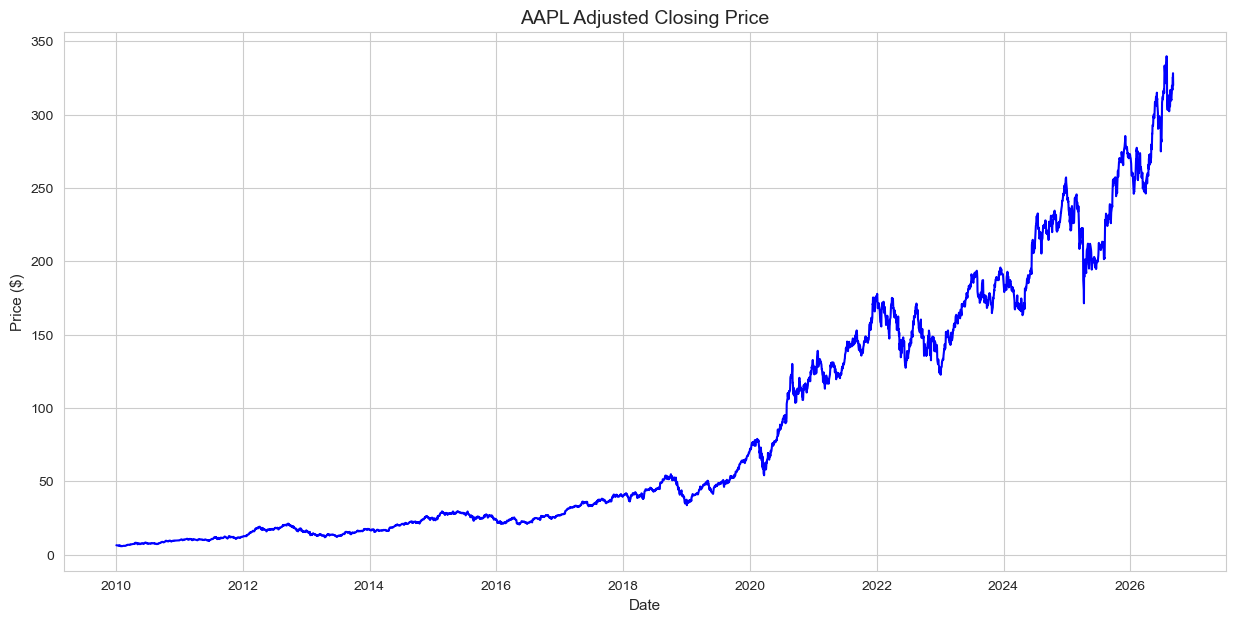

In [59]:
plt.figure(figsize=(15, 7))

plt.plot(
    df.index,
    df["Adj Close"],
    color="blue"
)

plt.title("AAPL Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.show()

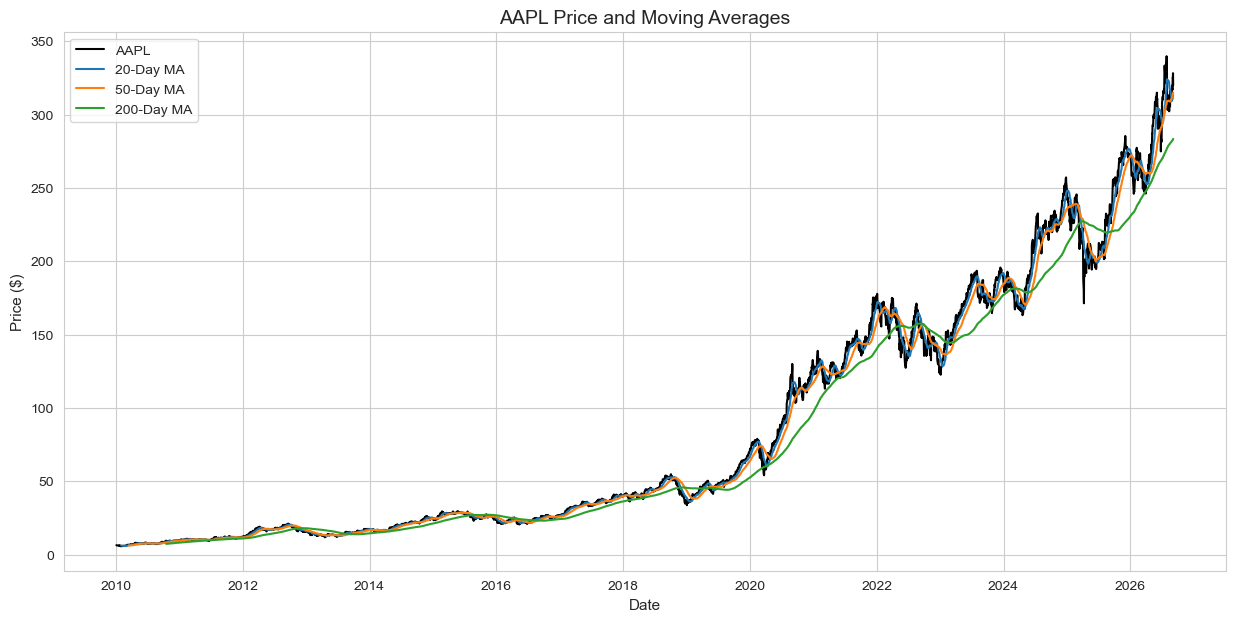

In [60]:
plt.figure(figsize=(15, 7))

plt.plot(
    df.index,
    df["Adj Close"],
    label="AAPL",
    color="black"
)

plt.plot(
    df.index,
    df["MA_20"],
    label="20-Day MA"
)

plt.plot(
    df.index,
    df["MA_50"],
    label="50-Day MA"
)

plt.plot(
    df.index,
    df["MA_200"],
    label="200-Day MA"
)

plt.title("AAPL Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.show()

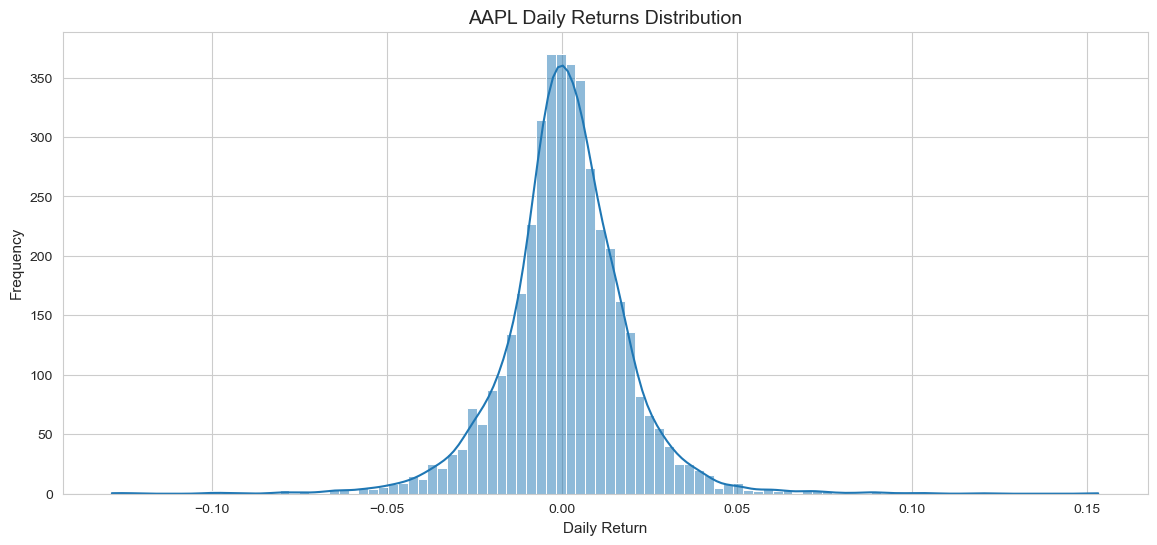

count    4193.000000
mean        0.001090
std         0.017719
min        -0.128647
25%        -0.007395
50%         0.001001
75%         0.010259
max         0.153288
Name: Daily_Return, dtype: float64

In [63]:
plt.figure(figsize=(14, 6))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=100,
    kde=True
)

plt.title("AAPL Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()
df["Daily_Return"].describe()

In [64]:
best_days = df.nlargest(
    10,
    "Daily_Return"
)[
    ["Adj Close", "Daily_Return", "Volume"]
]

best_days
worst_days = df.nsmallest(
    10,
    "Daily_Return"
)[
    ["Adj Close", "Daily_Return", "Volume"]
]

worst_days

Price,Adj Close,Daily_Return,Volume
Date,,,
2020-03-16,58.419952,-0.128647,322423600
2013-01-24,13.593949,-0.123558,1460852400
2019-01-03,33.707932,-0.099607,365248800
2020-03-12,59.871960,-0.098755,418474000
2025-04-03,201.947861,-0.092456,103419000
2020-09-03,117.149384,-0.080061,257599600
2014-01-28,15.667713,-0.079927,1065523200
2020-03-09,64.199013,-0.079092,286744800
2026-07-31,308.643829,-0.073539,132489100


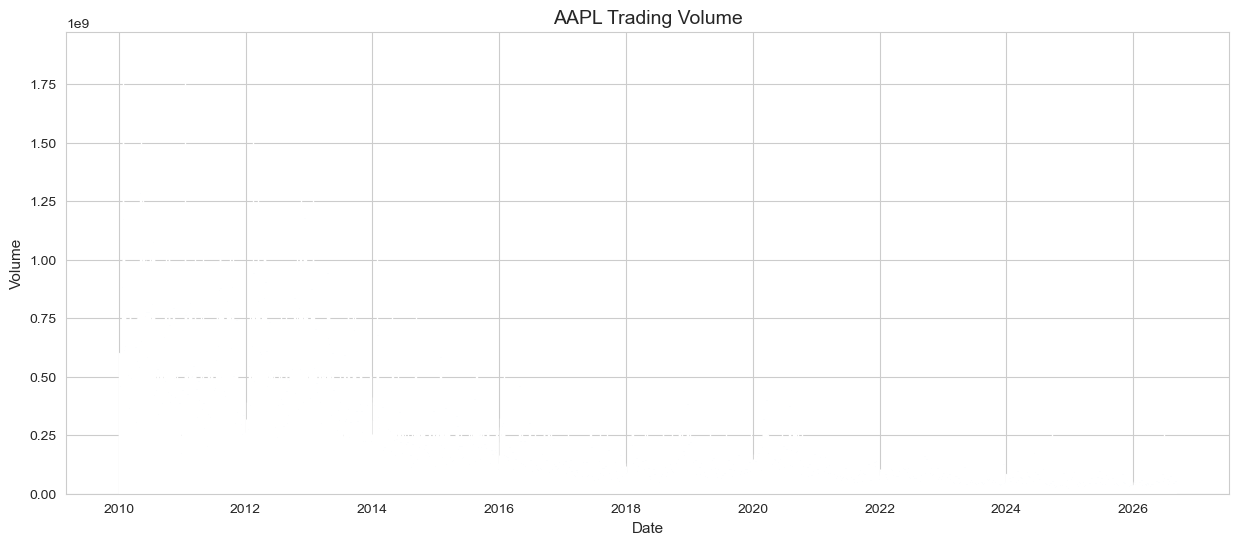

Price,Adj Close,Daily_Return,Volume
Date,,,
2011-01-18,10.188714,-0.022469,1880998000
2010-01-26,6.159590,0.014133,1867110000
2010-01-27,6.217613,0.009420,1722568400
2010-05-07,7.054485,-0.042193,1676018400
2012-02-15,14.885127,-0.023142,1506120000
2013-01-24,13.593949,-0.123558,1460852400
2012-03-14,17.634121,0.037810,1418844000
2010-05-06,7.365248,-0.038048,1285860800
2010-05-20,7.111314,-0.042603,1282915200


In [66]:
plt.figure(figsize=(15, 6))

plt.bar(
    df.index,
    df["Volume"],
    color="steelblue"
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()
df["Volume"].describe()
df.nlargest(
    10,
    "Volume"
)[
    ["Adj Close", "Daily_Return", "Volume"]
]

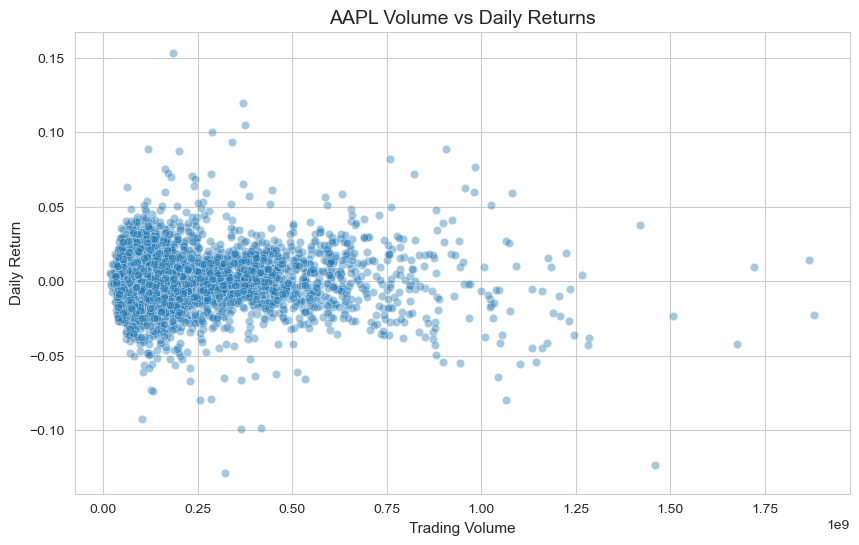

Price,Volume,Daily_Return
Price,,
Volume,1.000000,-0.040441
Daily_Return,-0.040441,1.000000


In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Volume",
    y="Daily_Return",
    alpha=0.4
)

plt.title("AAPL Volume vs Daily Returns")
plt.xlabel("Trading Volume")
plt.ylabel("Daily Return")

plt.show()
df[
    ["Volume", "Daily_Return"]
].corr()

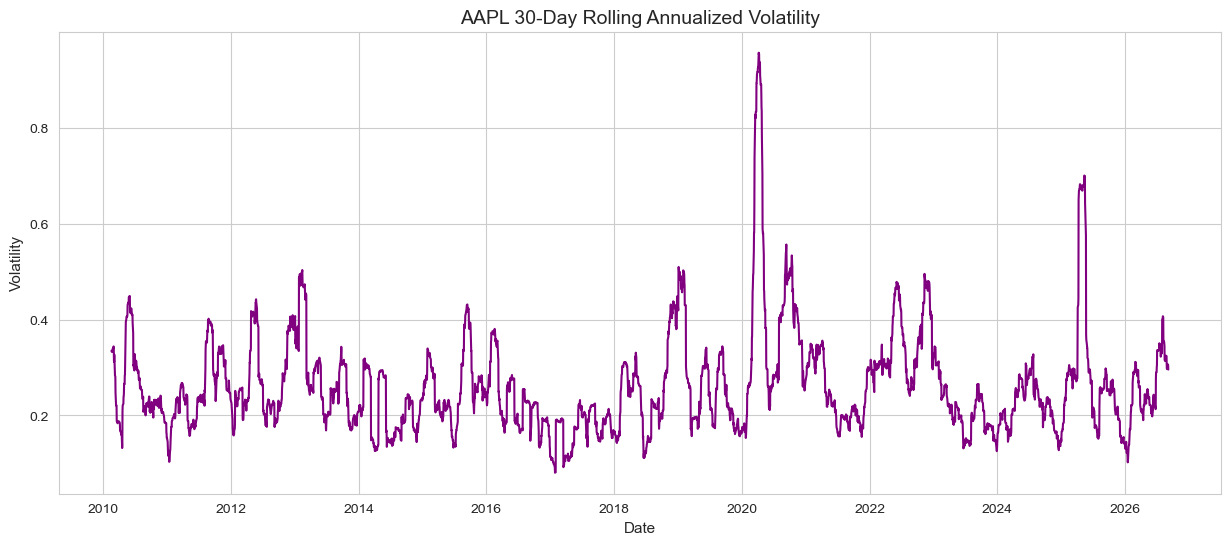

In [69]:
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Rolling_Volatility_30_Annualized"],
    color="purple"
)

plt.title("AAPL 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

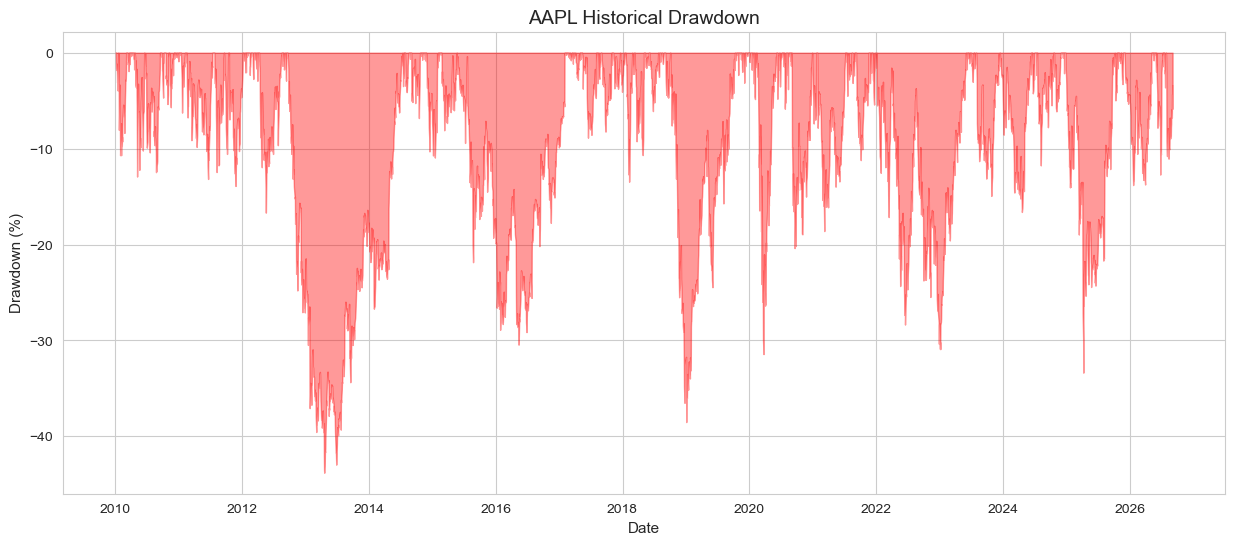

Maximum Drawdown: -43.80%


In [70]:
plt.figure(figsize=(15, 6))

plt.fill_between(
    df.index,
    df["Drawdown"] * 100,
    0,
    color="red",
    alpha=0.4
)

plt.title("AAPL Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.show()

max_drawdown = df["Drawdown"].min()

print(
    f"Maximum Drawdown: {max_drawdown:.2%}"
)

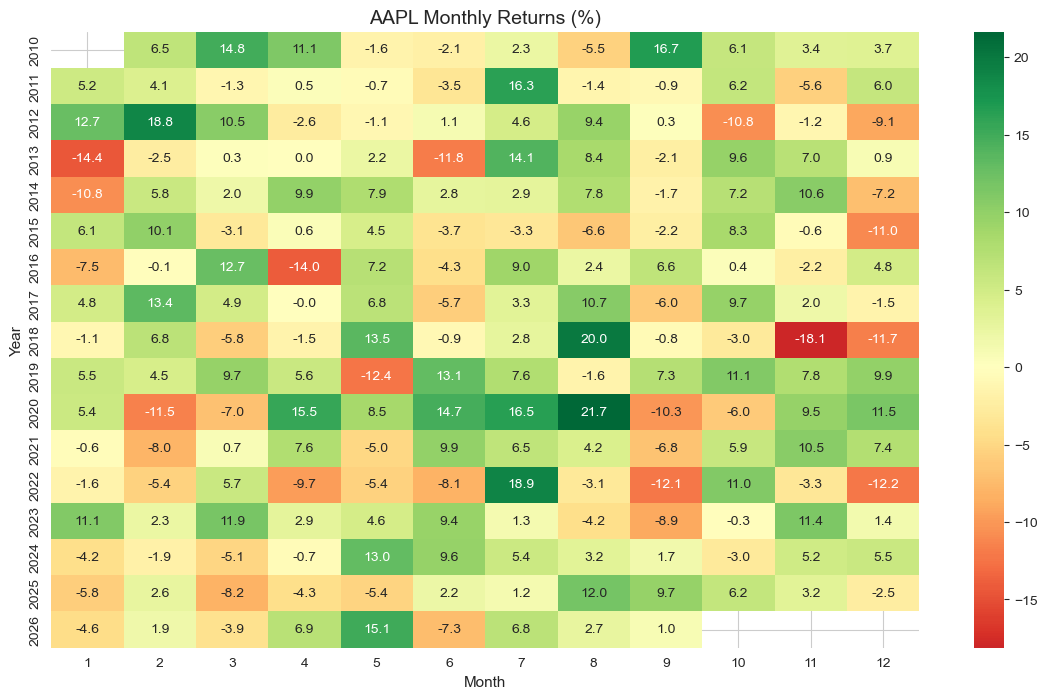

In [71]:
monthly_returns = (
    df["Adj Close"]
    .resample("ME")
    .last()
    .pct_change()
)
monthly_df = monthly_returns.to_frame(
    "Return"
)

monthly_df["Year"] = monthly_df.index.year

monthly_df["Month"] = monthly_df.index.month
monthly_pivot = monthly_df.pivot(
    index="Year",
    columns="Month",
    values="Return"
)
plt.figure(figsize=(14, 8))

sns.heatmap(
    monthly_pivot * 100,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1f"
)

plt.title("AAPL Monthly Returns (%)")

plt.show()

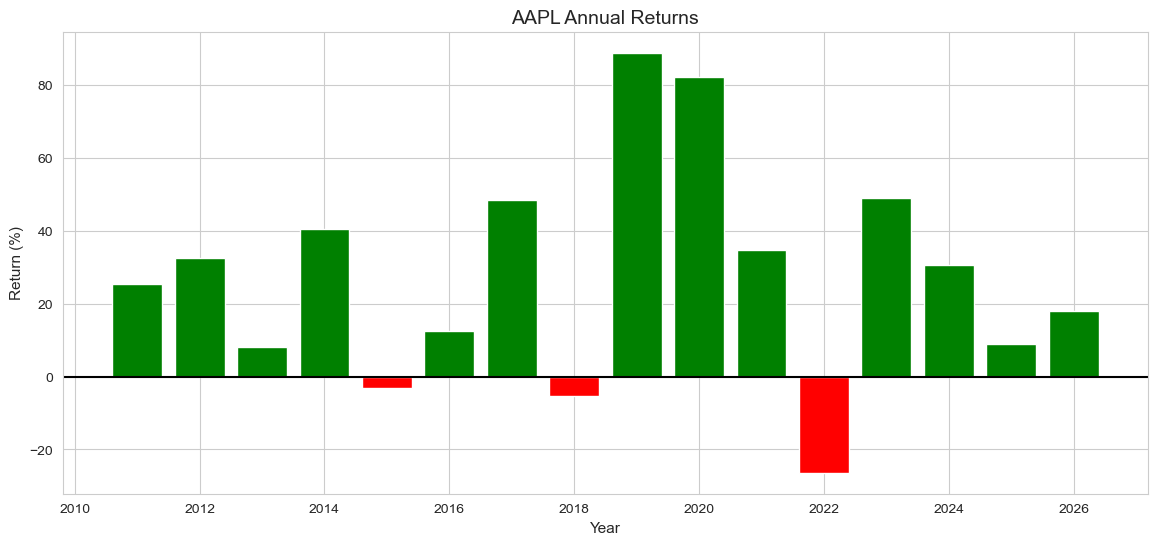

In [72]:
annual_returns = (
    df["Adj Close"]
    .resample("YE")
    .last()
    .pct_change()
)
annual_returns
colors = [
    "green" if x >= 0 else "red"
    for x in annual_returns
]

plt.figure(figsize=(14, 6))

plt.bar(
    annual_returns.index.year,
    annual_returns * 100,
    color=colors
)

plt.axhline(
    0,
    color="black"
)

plt.title("AAPL Annual Returns")
plt.xlabel("Year")
plt.ylabel("Return (%)")

plt.show()

In [73]:
sp500 = yf.download(
    "^GSPC",
    start="2010-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=False
)
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)
sp500["Daily_Return"] = (
    sp500["Adj Close"].pct_change()
)
aapl_returns = df["Daily_Return"]
comparison = pd.concat(
    [
        aapl_returns,
        sp500["Daily_Return"]
    ],
    axis=1
)

comparison.columns = [
    "AAPL",
    "S&P500"
]

comparison = comparison.dropna()

[*********************100%***********************]  1 of 1 completed


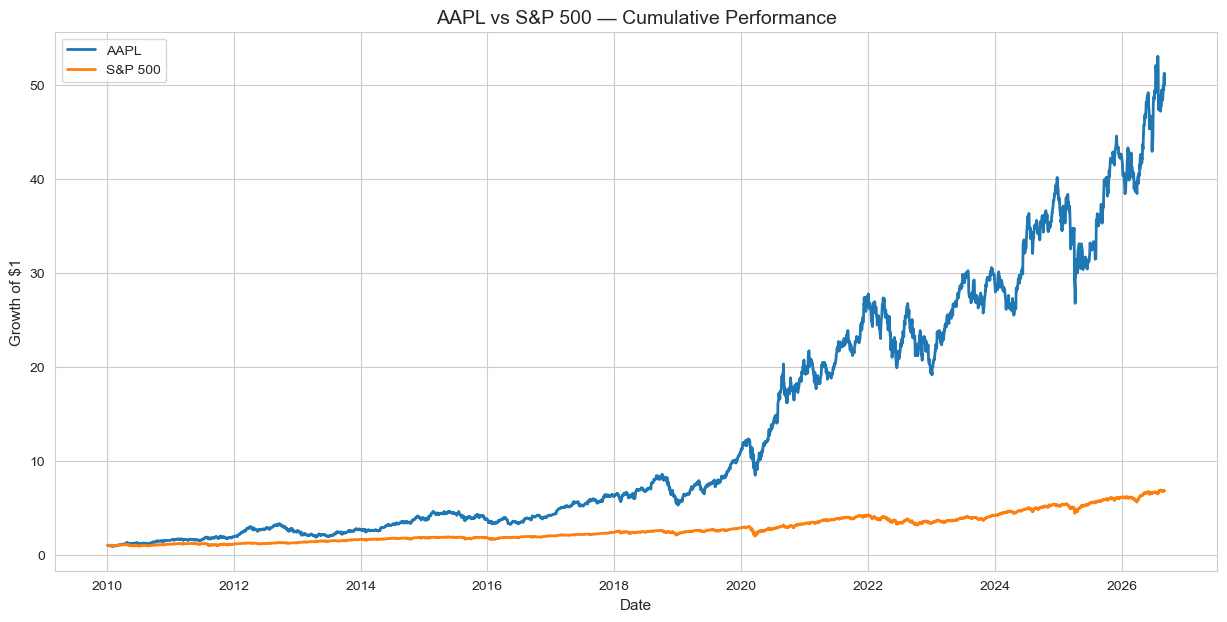

In [74]:
cumulative_comparison = (
    1 + comparison
).cumprod()
plt.figure(figsize=(15, 7))

plt.plot(
    cumulative_comparison["AAPL"],
    label="AAPL",
    linewidth=2
)

plt.plot(
    cumulative_comparison["S&P500"],
    label="S&P 500",
    linewidth=2
)

plt.title("AAPL vs S&P 500 — Cumulative Performance")

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()

plt.show()

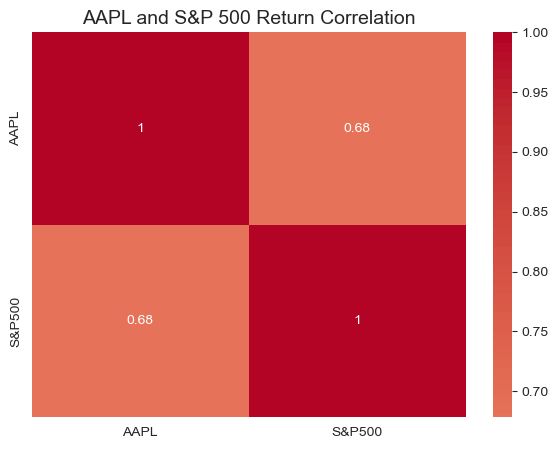

In [75]:
comparison.corr()
plt.figure(figsize=(7, 5))

sns.heatmap(
    comparison.corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("AAPL and S&P 500 Return Correlation")

plt.show()


In [76]:
covariance = comparison["AAPL"].cov(
    comparison["S&P500"]
)

market_variance = comparison["S&P500"].var()

beta = covariance / market_variance

print(f"AAPL Beta: {beta:.2f}")


AAPL Beta: 1.11


In [79]:
total_return = (
    df["Adj Close"].iloc[-1]
    / df["Adj Close"].iloc[0]
) - 1

annualized_volatility = (
    df["Daily_Return"].std()
    * np.sqrt(252)
)

best_day = df["Daily_Return"].max()

worst_day = df["Daily_Return"].min()

positive_days = (
    df["Daily_Return"] > 0
).sum()

negative_days = (
    df["Daily_Return"] < 0
).sum()

max_drawdown = df["Drawdown"].min()


print("========== AAPL SUMMARY ==========")

print(
    f"Analysis Period: {df.index.min().date()} "
    f"to {df.index.max().date()}"
)

print(
    f"Total Return: {total_return:.2%}"
)

print(
    f"Annualized Volatility: {annualized_volatility:.2%}"
)

print(
    f"Best Trading Day: {best_day:.2%}"
)

print(
    f"Worst Trading Day: {worst_day:.2%}"
)

print(
    f"Maximum Drawdown: {max_drawdown:.2%}"
)

print(
    f"Positive Days: {positive_days}"
)

print(
    f"Negative Days: {negative_days}"
)

print(
    f"AAPL Beta vs S&P 500: {beta:.2f}"
)


========== AAPL SUMMARY ==========
Analysis Period: 2010-01-04 to 2026-09-04
Total Return: 4898.78%
Annualized Volatility: 28.13%
Best Trading Day: 15.33%
Worst Trading Day: -12.86%
Maximum Drawdown: -43.80%
Positive Days: 2225
Negative Days: 1961
AAPL Beta vs S&P 500: 1.11
